In [1]:
# ============================================================
# Notebook: CVRP Pheromone (tau) vs Model Prior over H steps
# ============================================================

import os
import sys
import math
import random
from types import SimpleNamespace
from dataclasses import dataclass
from typing import List, Optional, Tuple, Dict, Any

import numpy as np
import torch
import matplotlib.pyplot as plt

from net import Net
from utils import build_pyg_data, load_val_dataset
from faco import MFACO_CVRP
from baselines import solve_with_hgs

EPS = 1e-12

def seed_all(seed: int = 1234):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def hgs_baseline_one(coords, demand, capacity, time_limit=2.0, seed=1):
    # solve_with_hgs returns scalar float
    return solve_with_hgs(coords, demand, capacity, time_limit=time_limit, seed=seed)

def plot_cost_and_gap_vs_hgs(opt_cost, base_trace, model_trace=None, title_prefix=""):
    H = len(base_trace.best_cost_H)
    x = np.arange(H)

    base_best = np.array(base_trace.best_cost_H, dtype=np.float64)
    base_gap = (base_best - opt_cost) / opt_cost * 100.0
    
    # Remove infs for plotting if any
    base_gap[base_best == float('inf')] = np.nan
    base_best[base_best == float('inf')] = np.nan

    plt.figure()
    plt.plot(x, base_best, marker="o", label="Base MFACO best@H")
    if model_trace is not None:
        model_best = np.array(model_trace.best_cost_H, dtype=np.float64)
        model_best[model_best == float('inf')] = np.nan
        plt.plot(x, model_best, marker="o", label="Model MFACO best@H")

    plt.axhline(opt_cost, linestyle="--", linewidth=1, label=f"HGS ({opt_cost:.2f})")
    plt.title(f"{title_prefix}Cost vs H")
    plt.xlabel("H step")
    plt.ylabel("Cost")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(x, base_gap, marker="o", label="Base gap (%)")
    if model_trace is not None:
        model_best = np.array(model_trace.best_cost_H, dtype=np.float64)
        model_gap = (model_best - opt_cost) / opt_cost * 100.0
        model_gap[model_best == float('inf')] = np.nan
        plt.plot(x, model_gap, marker="o", label="Model gap (%)")

    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.title(f"{title_prefix}Gap vs HGS over H")
    plt.xlabel("H step")
    plt.ylabel("Gap (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()

@dataclass
class Trace:
    priors: List[torch.Tensor]        # (n,k) CPU
    pher_before: List[torch.Tensor]   # (n,k) CPU
    probmat: List[torch.Tensor]       # (n,k) CPU

    # --- costs ---
    avg_cost_H: List[float]           # len H: average cost at last mini step
    best_cost_H: List[float]          # len H: best cost seen within that H step
    avg_cost_mini: List[float]        # len H*mini_H: avg cost each mini step
    best_cost_mini: List[float]       # len H*mini_H: best cost each mini step

def infer_with_logging(model, coords, demand, capacity, args, dynamic=True):
    if model:
        model.eval()

    aco = MFACO_CVRP(
        coords=coords,
        demand=demand,
        capacity=capacity,
        n_ants=args.n_ants,
        cand_list_size=args.k_sparse,
        backup_list_size=args.k_sparse,
        min_new_edges=args.min_new_edges,
        decay=args.rho,
        alpha=1.0,
        p_best=0.05,
        use_local_search=not args.no_local_search,
        disable_heuristic=args.disable_heuristic,
        extend_ls=args.extend_ls,
        smooth_mmas=not args.no_smooth_mmas,
        device=args.device,
        enable_torch_sync=True,
        normalized_heuristic=not args.no_normalized_heuristic
    )

    priors, pher_before, probmats = [], [], []
    avg_cost_H, best_cost_H = [], []
    avg_cost_mini, best_cost_mini = [], []

    invtemp = float(getattr(args, "invtemp", 1.0))

    with torch.no_grad():
        for t in range(args.H):
            # snapshot pheromone before update
            pher_before.append(aco.pheromone_sparse.detach().cpu().clone())

            prior = None
            if model is not None:
                pyg = build_pyg_data(aco, coords, demand, args.device, dynamic)
                prior = model(pyg).view(aco.n, aco.k)
                priors.append(prior.detach().cpu().clone())
            else:
                # Handle no-model case if we want uniform trace struct
                # We just leave prior as None for aco, but for trace we might want empty
                pass

            # compute probmat
            w = aco.prob_sparse_torch(invtemp=invtemp, prior=prior)
            prob = w / (w.sum(dim=1, keepdim=True) + EPS)
            probmats.append(prob.detach().cpu().clone())

            step_best = float("inf")
            step_avg_last = float("inf")

            for _ in range(args.mini_H):
                costs, perms, decoded, logps, traces = aco.sample(require_prob=False, prior=prior)
                
                c_avg = float(costs.mean())
                c_best = float(costs.min())
                
                avg_cost_mini.append(c_avg)
                best_cost_mini.append(c_best)
                
                step_best = min(step_best, c_best)
                step_avg_last = c_avg
                
                best_idx = int(costs.argmin())
                aco.update_pheromone(perms[best_idx], float(costs[best_idx]))

            avg_cost_H.append(step_avg_last)
            best_cost_H.append(step_best)

    return Trace(
        priors=priors,
        pher_before=pher_before,
        probmat=probmats,
        avg_cost_H=avg_cost_H,
        best_cost_H=best_cost_H,
        avg_cost_mini=avg_cost_mini,
        best_cost_mini=best_cost_mini
    )

# ---------------------------
# Visualization helpers (metrics)
# ---------------------------
def row_softmax(P: torch.Tensor) -> torch.Tensor:
    return torch.softmax(P.float(), dim=1)

def mean_row_kl(P_prev: torch.Tensor, P_cur: torch.Tensor) -> float:
    p = row_softmax(P_prev)
    q = row_softmax(P_cur)
    kl_row = (p * ((p + EPS).log() - (q + EPS).log())).sum(dim=1)
    return float(kl_row.mean())

def rel_l2_drift(P_prev: torch.Tensor, P_cur: torch.Tensor) -> float:
    a = P_prev.float()
    b = P_cur.float()
    return float((b - a).norm() / (a.norm() + EPS))

def top_set(P: torch.Tensor, frac: float = 0.05) -> set:
    v = P.flatten()
    m = v.numel()
    k = max(1, int(m * frac))
    idx = torch.topk(v, k).indices
    return set(idx.detach().cpu().tolist())

def top_turnover(P_prev: torch.Tensor, P_cur: torch.Tensor, frac: float = 0.05) -> float:
    A = top_set(P_prev, frac)
    B = top_set(P_cur, frac)
    jacc = len(A & B) / max(1, len(A | B))
    return float(1.0 - jacc)

def top1_flip_rate(P_prev: torch.Tensor, P_cur: torch.Tensor) -> float:
    a = P_prev.argmax(dim=1)
    b = P_cur.argmax(dim=1)
    return float((a != b).float().mean())

def safe_corr(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-12) -> float:
    a = a.detach().reshape(-1).to(device="cpu", dtype=torch.float32)
    b = b.detach().reshape(-1).to(device="cpu", dtype=torch.float32)
    mask = torch.isfinite(a) & torch.isfinite(b)
    if mask.sum() < 2: return float("nan")
    a, b = a[mask], b[mask]
    if float(a.std()) < eps or float(b.std()) < eps: return float("nan")
    a = a - a.mean()
    b = b - b.mean()
    denom = (a.norm() * b.norm()).clamp_min(eps)
    return float((a @ b) / denom)

def top_overlap_frac(a: torch.Tensor, b: torch.Tensor, frac: float = 0.05) -> float:
    a = a.flatten()
    b = b.flatten()
    m = a.numel()
    k = max(1, int(m * frac))
    ai = torch.topk(a, k).indices
    bi = torch.topk(b, k).indices
    inter = len(set(ai.cpu().tolist()).intersection(set(bi.cpu().tolist())))
    return inter / k

def row_top1_match_rate(a: torch.Tensor, b: torch.Tensor) -> float:
    return float((a.cpu().argmax(dim=1) == b.cpu().argmax(dim=1)).float().mean())

def plot_prior_change_over_H(priors: List[torch.Tensor], top_frac: float = 0.05):
    H = len(priors)
    l2, kl, turnover, flip = [], [], [], []
    for t in range(1, H):
        l2.append(rel_l2_drift(priors[t-1], priors[t]))
        kl.append(mean_row_kl(priors[t-1], priors[t]))
        turnover.append(top_turnover(priors[t-1], priors[t], frac=top_frac))
        flip.append(top1_flip_rate(priors[t-1], priors[t]))

    plt.figure()
    plt.plot(range(1, H), l2, marker="o"); plt.title("Prior L2 drift"); plt.show()
    plt.figure()
    plt.plot(range(1, H), kl, marker="o"); plt.title("Prior KL drift"); plt.show()
    plt.figure()
    plt.plot(range(1, H), turnover, marker="o"); plt.title("Prior Turnover"); plt.show()
    plt.figure()
    plt.plot(range(1, H), flip, marker="o"); plt.title("Prior Flip Rate"); plt.show()


/home/shora/Research/old/NGFACO/data


Loading validation dataset for N=5000...
Instance 0: N=5000, Cap=1.0, Demand Sum=490.46
Loading model from ../pretrained_extend_ls_mne_16/cvrp/cvrp5000.pt
Running Base MFACO (No Model)...
[431.44921875, 429.41357421875, 428.44976806640625, 428.10430908203125, 427.9361877441406, 427.414794921875, 427.045166015625, 426.8126220703125, 426.49884033203125, 426.1002502441406]
Running Model MFACO (With Prior)...
[432.6900634765625, 429.61773681640625, 427.70501708984375, 426.42779541015625, 425.54278564453125, 424.87432861328125, 424.4159851074219, 424.14801025390625, 423.7933349609375, 423.5472412109375]
Computing HGS optimal cost...
HGS Optimal: 422.8594


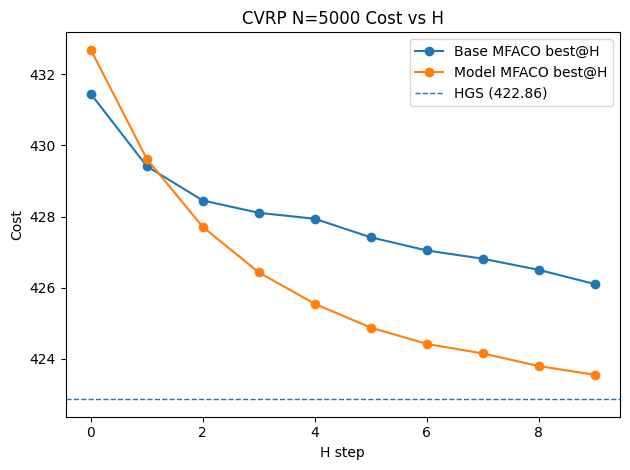

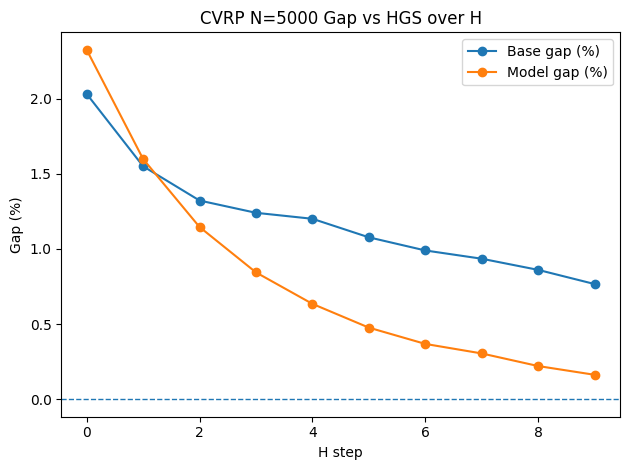

Plotting Prior Changes...


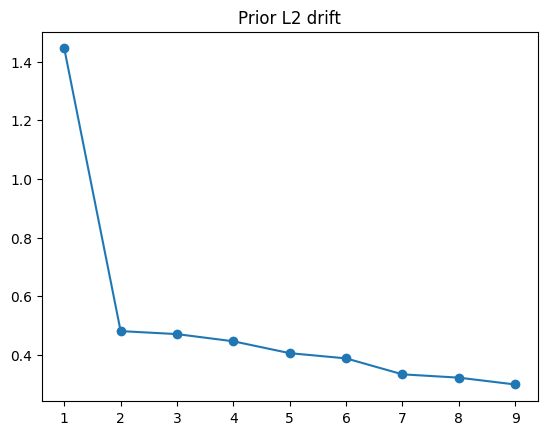

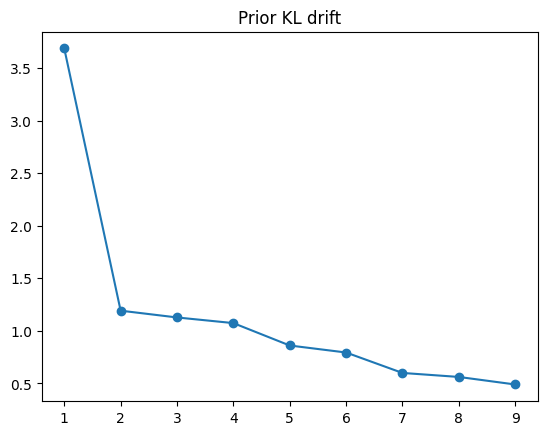

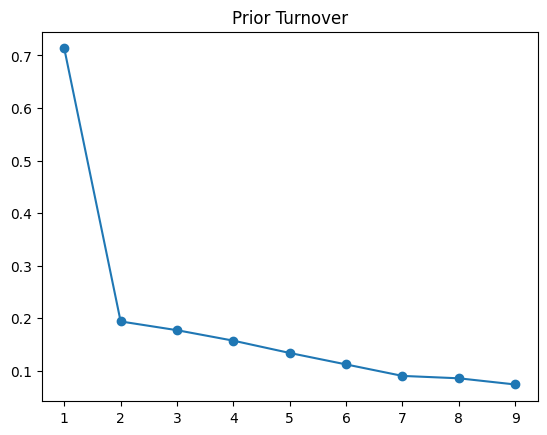

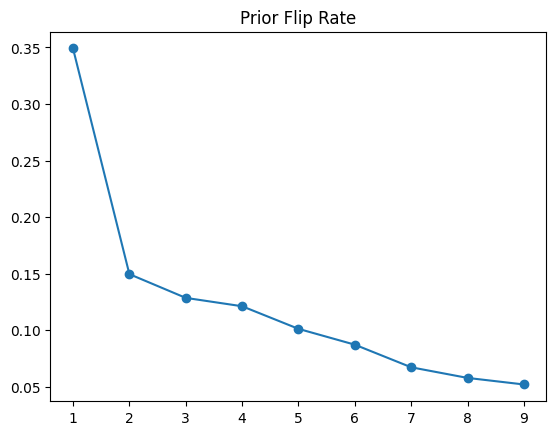

Alignment Metrics (Pheromone vs Prior)...
Step 0: Corr=nan, Top5% Overlap=0.0486
Step 1: Corr=-0.4400, Top5% Overlap=0.0000
Step 2: Corr=-0.4397, Top5% Overlap=0.0000
Step 3: Corr=-0.4392, Top5% Overlap=0.0000
Step 4: Corr=-0.4394, Top5% Overlap=0.0000
Step 5: Corr=-0.4392, Top5% Overlap=0.0000
Step 6: Corr=-0.4391, Top5% Overlap=0.0000
Step 7: Corr=-0.4386, Top5% Overlap=0.0000
Step 8: Corr=-0.4388, Top5% Overlap=0.0000
Step 9: Corr=-0.4387, Top5% Overlap=0.0000


In [2]:
# ---------------------------
# Main execution cell
# ---------------------------

args = SimpleNamespace(
    n_node=5000,
    k_sparse=32,
    n_ants=100,
    H=10,
    mini_H=100,  # steps per iteration
    rho=0.5,
    min_new_edges=8,
    device="cuda:0" if torch.cuda.is_available() else "cpu",
    no_local_search=False,
    disable_heuristic=False,
    extend_ls=True,
    no_smooth_mmas=False,
    no_normalized_heuristic=True,
    checkpoint="../pretrained_extend_ls_mne_16/cvrp/cvrp5000.pt",
    idx=0  # Instance index
)

seed_all(1234)

# Load dataset
print(f"Loading validation dataset for N={args.n_node}...")
try:
    val_dataset = load_val_dataset(args.n_node, "cpu")
    # Select ONE instance
    coords = val_dataset.tensors[0][args.idx].numpy()
    demand = val_dataset.tensors[1][args.idx].numpy()
    capacity = float(val_dataset.tensors[2][args.idx])
except FileNotFoundError:
    print("Dataset not found, generating random instance.")
    # from utils import gen_instance_for_mfaco
    # coords, demand, capacity = gen_instance_for_mfaco(args.n_node, "cpu")
    # For notebook we assume utils import works
    import cvrp.utils
    coords, demand, capacity = cvrp.utils.gen_instance_for_mfaco(args.n_node, "cpu")
    coords = coords.numpy()
    demand = demand.numpy()

print(f"Instance {args.idx}: N={args.n_node}, Cap={capacity}, Demand Sum={demand.sum():.2f}")

# Load Model
model = None
if args.checkpoint != "none" and os.path.exists(args.checkpoint):
    print(f"Loading model from {args.checkpoint}")
    ckpt = torch.load(args.checkpoint, map_location=args.device)
    model = Net(logit_net=True).to(args.device)
    if "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
    else:
        model.load_state_dict(ckpt)
    model.eval()
else:
    print("No checkpoint loaded (using random model for demo or base only).")
    # Initialize random model just to show difference if needed
    model = Net(logit_net=True).to(args.device)

# ---------------------------
# Run Baseline (Base MFACO)
# ---------------------------
print("Running Base MFACO (No Model)...")
base_args = SimpleNamespace(**vars(args))
base_args.disable_heuristic = False # Important for base
base_trace = infer_with_logging(None, coords, demand, capacity, base_args, dynamic=False)
print(base_trace.best_cost_H)

# ---------------------------
# Run Model MFACO
# ---------------------------
print("Running Model MFACO (With Prior)...")
# Typically trained models disable heuristic or use it alongside
# Let's assume we want to see model effect clearly
model_trace = infer_with_logging(model, coords, demand, capacity, args, dynamic=True)
print(model_trace.best_cost_H)
# ---------------------------
# Compute HGS Optimal
# ---------------------------
print("Computing HGS optimal cost...")
opt_cost = hgs_baseline_one(coords, demand, capacity, time_limit=2.0)
print(f"HGS Optimal: {opt_cost}")

# ---------------------------
# Plotting
# ---------------------------
plot_cost_and_gap_vs_hgs(opt_cost, base_trace, model_trace, title_prefix=f"CVRP N={args.n_node} ")

if len(model_trace.priors) > 0:
    print("Plotting Prior Changes...")
    plot_prior_change_over_H(model_trace.priors)

    print("Alignment Metrics (Pheromone vs Prior)...")
    for t in range(len(model_trace.priors)):
        tau = model_trace.pher_before[t]
        pr = model_trace.priors[t]
        corr = safe_corr(tau, pr)
        ov = top_overlap_frac(tau, pr)
        print(f"Step {t}: Corr={corr:.4f}, Top5% Overlap={ov:.4f}")
